# Day 2 RNN

### Importing libraries

In [1]:
# Libraries

import random

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU
from tensorflow.keras.callbacks import EarlyStopping

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

I0000 00:00:1780107136.944802  255677 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780107139.092927  255677 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780107145.182324  255677 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


### Load & inspect data

In [2]:
# Load and inspect Bitcoin data

bitcoin = pd.read_csv("dc.csv")

bitcoin = bitcoin.rename(
    columns={"Unnamed: 0": "date"}
)

bitcoin["date"] = pd.to_datetime(bitcoin["date"])

bitcoin = (
    bitcoin
    .sort_values("date")
    .reset_index(drop=True)
)

print(bitcoin.shape)

bitcoin.head()

(1000, 6)


,date,open_USD,high_USD,low_USD,close_USD,volume
0,2018-05-07,9661.02,9689.67,9181.00,9365.00,33787
1,2018-05-08,9365.00,9475.70,9060.54,9187.56,25533
2,2018-05-09,9178.00,9390.00,8965.00,9310.00,25673
3,2018-05-10,9310.00,9395.12,8970.00,9002.20,25055
4,2018-05-11,9002.21,9016.80,8341.00,8400.00,48227


In [3]:
# Basic inspection

bitcoin.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       1000 non-null   datetime64[us]
 1   open_USD   1000 non-null   float64       
 2   high_USD   1000 non-null   float64       
 3   low_USD    1000 non-null   float64       
 4   close_USD  1000 non-null   float64       
 5   volume     1000 non-null   int64         
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 47.0 KB


In [4]:
# Summary statistics

bitcoin.describe()

,date,open_USD,high_USD,low_USD,close_USD,volume
count,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2019-09-18 12:00:00,9285.762120,9542.880270,9011.393200,9310.335850,53100.498000
min,2018-05-07 00:00:00,3211.710000,3276.500000,3156.260000,3211.720000,5743.000000
25%,2019-01-11 18:00:00,6467.192500,6582.255000,6325.015000,6466.762500,30045.750000
50%,2019-09-18 12:00:00,8189.695000,8351.630000,8002.045000,8189.330000,43795.500000
75%,2020-05-25 06:00:00,10216.860000,10419.562500,9907.977500,10220.170000,64909.250000
max,2021-01-30 00:00:00,40586.960000,41950.000000,38720.000000,40582.810000,402201.000000
std,NaN,5793.522832,6075.604427,5483.524463,5846.917681,35329.832031


Visualizing the target variable

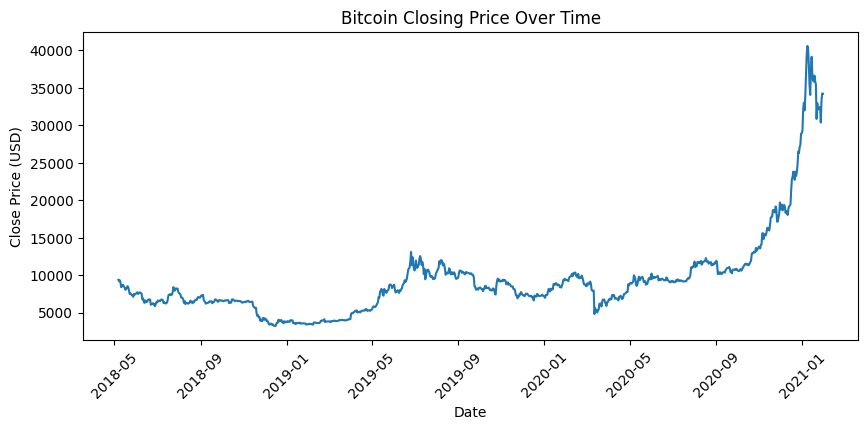

In [5]:
# Visualize closing price over time

plt.figure(figsize=(10, 4))

plt.plot(
    bitcoin["date"],
    bitcoin["close_USD"]
)

plt.title("Bitcoin Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")

plt.ticklabel_format(
    style="plain",
    axis="y"
)

plt.xticks(rotation=45)

plt.show()

### Preparing data for recurrent modeling

In [6]:
# Prepare Bitcoin data for recurrent models

features = [
    "open_USD",
    "high_USD",
    "low_USD",
    "close_USD",
    "volume"
]

target_col = "close_USD"

bitcoin_model = bitcoin[["date"] + features].copy()

print("Unique dates:", bitcoin_model["date"].nunique())
print("Rows:", len(bitcoin_model))

scaler_bitcoin = MinMaxScaler(feature_range=(0, 1))

scaled_features = scaler_bitcoin.fit_transform(
    bitcoin_model[features]
)

look_back = 10                                                  # use 10 previous days to predict next close

target_index = features.index(target_col)

Unique dates: 1000
Rows: 1000


### Useful functions

In [7]:
# Function to create recurrent sequence windows

def create_sequences(dataset, target_index, look_back=10):

    X, y = [], []

    for i in range(len(dataset) - look_back):

        X.append(
            dataset[i:i + look_back, :]
        )                                                       # previous look_back days

        y.append(
            dataset[i + look_back, target_index]
        )                                                       # next day's close_USD

    return np.array(X), np.array(y)

In [8]:
# Function to visualize training curves

def plot_training_curves(history, title):

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Loss
    axes[0].plot(
        history.history["loss"],
        label="Training Loss"
    )

    axes[0].plot(
        history.history["val_loss"],
        label="Validation Loss"
    )

    axes[0].set_title(title + " Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("MSE Loss")

    axes[0].legend()

    # MAE
    axes[1].plot(
        history.history["mean_absolute_error"],
        label="Training MAE"
    )

    axes[1].plot(
        history.history["val_mean_absolute_error"],
        label="Validation MAE"
    )

    axes[1].set_title(title + " MAE")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Mean Absolute Error")

    axes[1].legend()

    plt.tight_layout()

    plt.show()

In [9]:
# Function to evaluate forecasting performance

def evaluate_and_plot(
    model,
    trainX,
    testX,
    trainY,
    testY,
    scaler,
    target_index,
    title
):

    # Predictions
    train_pred = model.predict(trainX)
    test_pred = model.predict(testX)

    # Create arrays for inverse scaling
    train_dummy = np.zeros((len(train_pred), len(features)))
    test_dummy = np.zeros((len(test_pred), len(features)))

    train_dummy[:, target_index] = train_pred.flatten()
    test_dummy[:, target_index] = test_pred.flatten()

    trainY_dummy = np.zeros((len(trainY), len(features)))
    testY_dummy = np.zeros((len(testY), len(features)))

    trainY_dummy[:, target_index] = trainY
    testY_dummy[:, target_index] = testY

    # Inverse transform
    train_pred_inv = scaler.inverse_transform(train_dummy)[:, target_index]
    test_pred_inv = scaler.inverse_transform(test_dummy)[:, target_index]

    trainY_inv = scaler.inverse_transform(trainY_dummy)[:, target_index]
    testY_inv = scaler.inverse_transform(testY_dummy)[:, target_index]

    # Metrics
    train_rmse = np.sqrt(mean_squared_error(trainY_inv, train_pred_inv))
    test_rmse = np.sqrt(mean_squared_error(testY_inv, test_pred_inv))

    train_mae = mean_absolute_error(trainY_inv, train_pred_inv)
    test_mae = mean_absolute_error(testY_inv, test_pred_inv)

    print(f"{title} Train RMSE: {train_rmse:.2f}")
    print(f"{title} Test RMSE: {test_rmse:.2f}")

    print(f"{title} Train MAE: {train_mae:.2f}")
    print(f"{title} Test MAE: {test_mae:.2f}")

    # Plot predictions
    plt.figure(figsize=(10, 4))

    plt.plot(
        testY_inv,
        label="Actual"
    )

    plt.plot(
        test_pred_inv,
        label="Predicted"
    )

    plt.title(title + " Test Predictions")

    plt.xlabel("Test time index")
    plt.ylabel("Bitcoin Close Price (USD)")

    plt.ticklabel_format(
        style="plain",
        axis="y"
    )

    plt.legend()

    plt.show()

In [10]:
# Function to compare model metrics

def evaluate_metrics(
    model,
    testX,
    testY,
    scaler,
    target_index
):

    test_pred = model.predict(testX)

    test_dummy = np.zeros((len(test_pred), len(features)))
    test_dummy[:, target_index] = test_pred.flatten()

    testY_dummy = np.zeros((len(testY), len(features)))
    testY_dummy[:, target_index] = testY

    test_pred_inv = scaler.inverse_transform(test_dummy)[:, target_index]
    testY_inv = scaler.inverse_transform(testY_dummy)[:, target_index]

    rmse = np.sqrt(mean_squared_error(testY_inv, test_pred_inv))
    mae = mean_absolute_error(testY_inv, test_pred_inv)

    return rmse, mae

### Creating train/test recurrent tensors

In [11]:
# Create train/test recurrent tensors

train_size = int(len(scaled_features) * 0.8)                    # chronological 80/20 split

train_bitcoin = scaled_features[:train_size]                    # earlier data
test_bitcoin = scaled_features[train_size:]                     # held-out future data

trainX_bitcoin, trainY_bitcoin = create_sequences(
    train_bitcoin,
    target_index,
    look_back
)

testX_bitcoin, testY_bitcoin = create_sequences(
    test_bitcoin,
    target_index,
    look_back
)

print("trainX_bitcoin shape:", trainX_bitcoin.shape)
print("testX_bitcoin shape:", testX_bitcoin.shape)
print("trainY_bitcoin shape:", trainY_bitcoin.shape)
print("testY_bitcoin shape:", testY_bitcoin.shape)

trainX_bitcoin shape: (790, 10, 5)
testX_bitcoin shape: (190, 10, 5)
trainY_bitcoin shape: (790,)
testY_bitcoin shape: (190,)


### Baseline SimpleRNN model

In [12]:
# Build and train baseline SimpleRNN model

simple_rnn_model = Sequential([
    SimpleRNN(
        8,                                     # small baseline recurrent layer
        activation="tanh",                     # standard activation for SimpleRNN
        input_shape=(look_back, trainX_bitcoin.shape[2])
    ),                                         # input shape = timesteps, features

    Dense(1)                                   # output layer: predict next close_USD value
])

simple_rnn_model.compile(
    optimizer="adam",                          # adaptive gradient-based optimizer
    loss="mean_squared_error",                 # regression loss
    metrics=["mean_absolute_error"]            # easier-to-interpret training metric
)

simple_rnn_history = simple_rnn_model.fit(
    trainX_bitcoin,
    trainY_bitcoin,
    epochs=50,                                 # baseline training limit
    batch_size=16,                             # update weights after each batch
    validation_split=0.2,                      # last 20% of training data used for validation
    shuffle=False,                             # preserve chronological order
    verbose=1
)

W0000 00:00:1780107155.357799  255677 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1780107155.395807  255677 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1780107156.347657  255677 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5199 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Laptop GPU, pci bus id: 0000:64:00.0, compute capability: 12.0a
/home/jfigg/miniforge3/envs/keras_env_wsl/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model inste

Epoch 1/50


I0000 00:00:1780107161.720500  258890 service.cc:153] XLA service 0x7400d00310e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780107161.720648  258890 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070 Laptop GPU, Compute Capability 12.0a (Driver: 13.1.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1780107161.847755  258890 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1780107162.304942  258890 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1780107162.383735  258890 dot_merger.cc:481] Merging Dots in computation: sequential_1_simple_rnn_1_while_body_1117_grad_1309_const_0__.17.clone.clone.clone.clone.clone


 9/40 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0317 - mean_absolute_error: 0.1690

I0000 00:00:1780107165.447524  258890 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


35/40 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0188 - mean_absolute_error: 0.1169

I0000 00:00:1780107166.289476  258893 dot_merger.cc:481] Merging Dots in computation: sequential_1_simple_rnn_1_while_body_1117_grad_1309_const_0__.17.clone.clone.clone.clone.clone


40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 118ms/step - loss: 0.0108 - mean_absolute_error: 0.0820 - val_loss: 0.0113 - val_mean_absolute_error: 0.0747
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0041 - mean_absolute_error: 0.0477 - val_loss: 0.0080 - val_mean_absolute_error: 0.0571
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0029 - mean_absolute_error: 0.0402 - val_loss: 0.0062 - val_mean_absolute_error: 0.0496
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0022 - mean_absolute_error: 0.0343 - val_loss: 0.0049 - val_mean_absolute_error: 0.0438
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0018 - mean_absolute_error: 0.0304 - val_loss: 0.0039 - val_mean_absolute_error: 0.0391
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0015 - mean_absolute_error: 0.0279 - val_loss: 0.0032 - val_mean_absolute_error: 0.0353
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0013 - mean_absolute_error: 0.0259 - val_loss: 0.0026 

Visualizing training

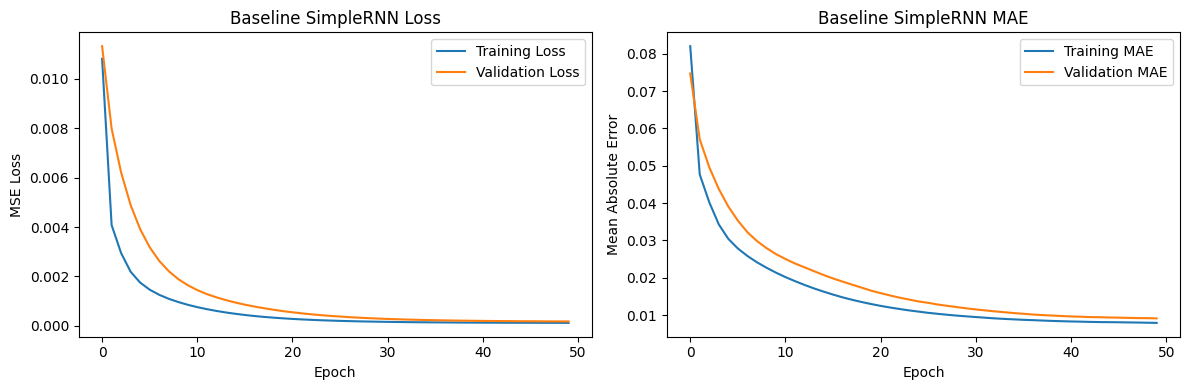

In [13]:
# Visualize SimpleRNN training performance

plot_training_curves(
    simple_rnn_history,
    "Baseline SimpleRNN"
)

Evaluation on test data

25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 185ms/step
Baseline SimpleRNN Train RMSE: 492.60
Baseline SimpleRNN Test RMSE: 3949.76
Baseline SimpleRNN Train MAE: 363.83
Baseline SimpleRNN Test MAE: 2406.94


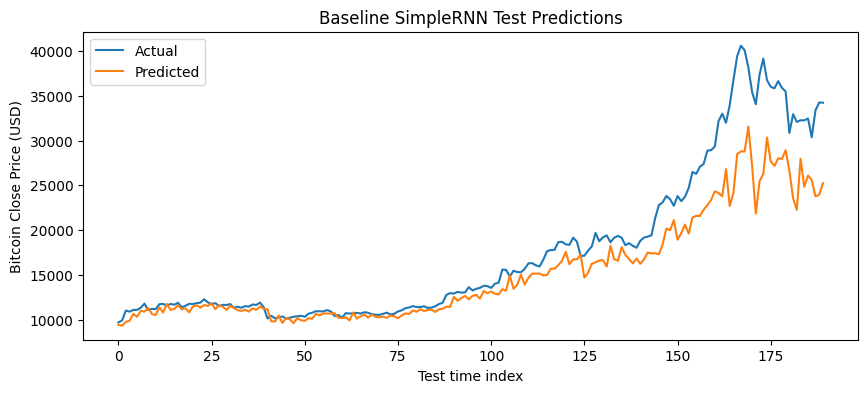

In [ ]:
# Evaluate SimpleRNN on held-out future test data

evaluate_and_plot(
    simple_rnn_model,
    trainX_bitcoin,
    testX_bitcoin,
    trainY_bitcoin,
    testY_bitcoin,
    scaler_bitcoin,
    target_index,
    "Baseline SimpleRNN"
)

### Baseline LSTM Model

In [15]:
# Build and train baseline LSTM model

lstm_model = Sequential([
    LSTM(
        8,                                     # small baseline LSTM layer
        activation="tanh",                     # standard LSTM hidden-state activation
        input_shape=(look_back, trainX_bitcoin.shape[2])
    ),                                         # input shape = timesteps, features

    Dense(1)                                   # output layer: predict next close_USD value
])

lstm_model.compile(
    optimizer="adam",                          # adaptive gradient-based optimizer
    loss="mean_squared_error",                 # regression loss
    metrics=["mean_absolute_error"]            # easier-to-interpret training metric
)

lstm_history = lstm_model.fit(
    trainX_bitcoin,
    trainY_bitcoin,
    epochs=50,                                 # baseline training limit
    batch_size=16,                             # update weights after each batch
    validation_split=0.2,                      # last 20% of training data used for validation
    shuffle=False,                             # preserve chronological order
    verbose=1
)

Epoch 1/50


/home/jfigg/miniforge3/envs/keras_env_wsl/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - loss: 0.0018 - mean_absolute_error: 0.0332 - val_loss: 0.0052 - val_mean_absolute_error: 0.0536
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0011 - mean_absolute_error: 0.0257 - val_loss: 0.0043 - val_mean_absolute_error: 0.0484
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 5.7133e-04 - mean_absolute_error: 0.0183 - val_loss: 0.0033 - val_mean_absolute_error: 0.0409
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 3.8705e-04 - mean_absolute_error: 0.0150 - val_loss: 0.0024 - val_mean_absolute_error: 0.0340
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 3.2299e-04 - mean_absolute_error: 0.0139 - val_loss: 0.0019 - val_mean_absolute_error: 0.0293
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 2.8938e-04 - mean_absolute_error: 0.0132 - val_loss: 0.0015 - val_mean_absolute_error: 0.0259
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 2.6537e-04 - mean_absolute_error: 0.0126 -

Visualizing training

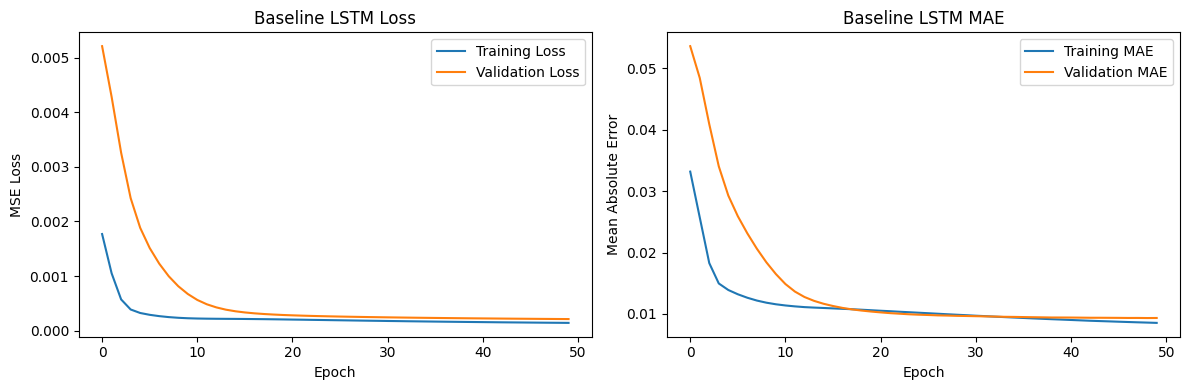

In [16]:
# Visualize LSTM training performance

plot_training_curves(
    lstm_history,
    "Baseline LSTM"
)

Evaluation on test data

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Baseline LSTM Train RMSE: 434.45
Baseline LSTM Test RMSE: 2398.89
Baseline LSTM Train MAE: 299.79
Baseline LSTM Test MAE: 1580.68


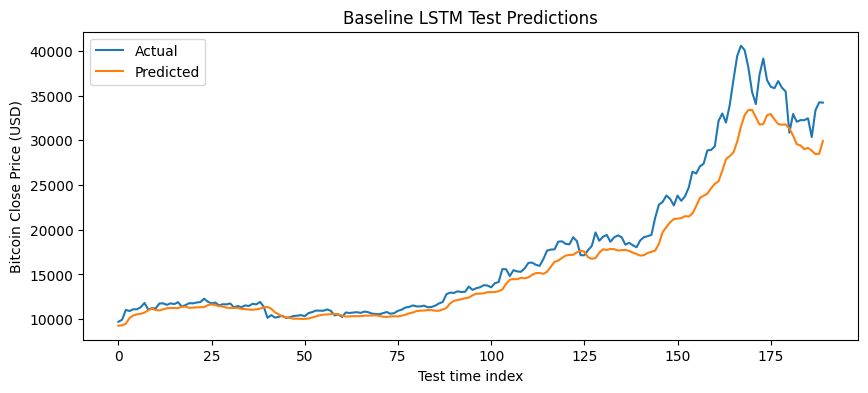

In [17]:
# Evaluate LSTM on held-out future test data

evaluate_and_plot(
    lstm_model,
    trainX_bitcoin,
    testX_bitcoin,
    trainY_bitcoin,
    testY_bitcoin,
    scaler_bitcoin,
    target_index,
    "Baseline LSTM"
)

### Baseline GRU model

In [18]:
# Build and train baseline GRU model

gru_model = Sequential([
    GRU(
        8,                                      # intentionally small baseline GRU layer
        activation="tanh",                     # standard GRU hidden-state activation
        input_shape=(look_back, trainX_bitcoin.shape[2])
    ),                                         # input shape = timesteps, features

    Dense(1)                                   # output layer: predict next close_USD value
])

gru_model.compile(
    optimizer="adam",                          # adaptive gradient-based optimizer
    loss="mean_squared_error",                 # regression loss
    metrics=["mean_absolute_error"]            # easier-to-interpret training metric
)

gru_history = gru_model.fit(
    trainX_bitcoin,
    trainY_bitcoin,
    epochs=50,                                 # baseline training limit
    batch_size=16,                             # update weights after each batch
    validation_split=0.2,                      # last 20% of training data used for validation
    shuffle=False,                             # preserve chronological order
    verbose=1
)

Epoch 1/50


/home/jfigg/miniforge3/envs/keras_env_wsl/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0039 - mean_absolute_error: 0.0515 - val_loss: 0.0022 - val_mean_absolute_error: 0.0362
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0011 - mean_absolute_error: 0.0279 - val_loss: 0.0020 - val_mean_absolute_error: 0.0395
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 3.3695e-04 - mean_absolute_error: 0.0147 - val_loss: 8.5777e-04 - val_mean_absolute_error: 0.0239
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 1.5669e-04 - mean_absolute_error: 0.0092 - val_loss: 3.7555e-04 - val_mean_absolute_error: 0.0138
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 1.6616e-04 - mean_absolute_error: 0.0093 - val_loss: 2.3577e-04 - val_mean_absolute_error: 0.0106
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 1.8020e-04 - mean_absolute_error: 0.0095 - val_loss: 1.7568e-04 - val_mean_absolute_error: 0.0090
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 1.8723e-04 - mean_absolute

Visualizing training

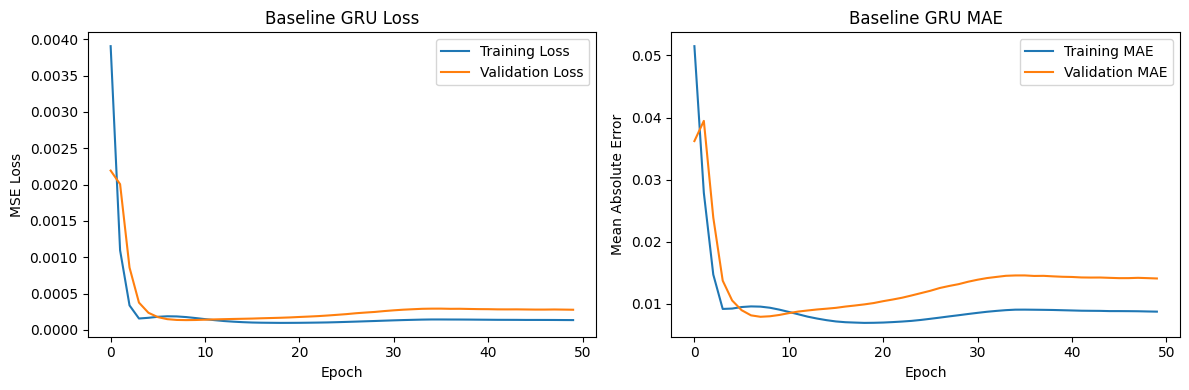

In [19]:
# Visualize GRU training performance

plot_training_curves(
    gru_history,
    "Baseline GRU"
)

Evaluation on test data

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Baseline GRU Train RMSE: 560.90
Baseline GRU Test RMSE: 4731.79
Baseline GRU Train MAE: 438.37
Baseline GRU Test MAE: 3247.64


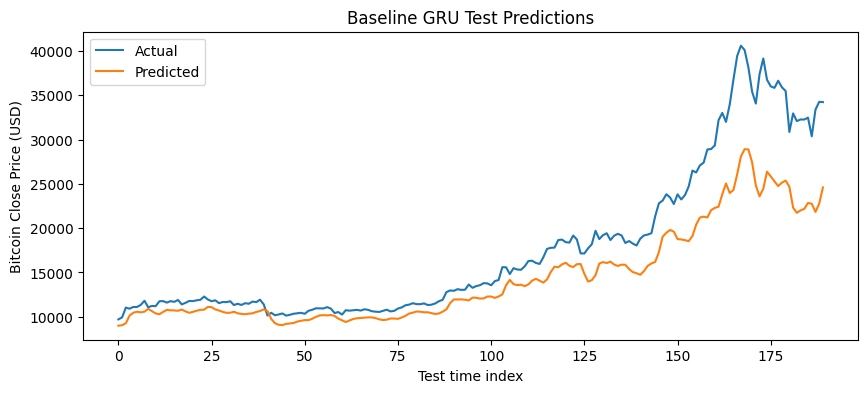

In [20]:
# Evaluate GRU on held-out future test data

evaluate_and_plot(
    gru_model,
    trainX_bitcoin,
    testX_bitcoin,
    trainY_bitcoin,
    testY_bitcoin,
    scaler_bitcoin,
    target_index,
    "Baseline GRU"
)

### Activity: Improving Forecasting Models

Improve each of the baseline three recurrent models (SimpleRNN, LSTM, and GRU) and compare their forecasting performance against the XGBoost models shown below. You should provide the code for each improved model and include a markdown cell after each model describing what you changed, what you explored, and how the changes affected performance. After completing your experiments, provide a short overall summary discussing which approaches appeared most effective, which models were easiest or hardest to tune, and what tradeoffs you observed between model complexity, training stability, and forecasting performance.

#### RNN Improvement: add capacity

/home/jfigg/miniforge3/envs/keras_env_wsl/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50


I0000 00:00:1780107675.172181  258887 dot_merger.cc:481] Merging Dots in computation: sequential_4_1_simple_rnn_2_1_while_body_56786_grad_56989_const_0__.18.clone.clone.clone.clone.clone
I0000 00:00:1780107675.172547  258887 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_57458__.19


38/40 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0058 - mean_absolute_error: 0.0562

I0000 00:00:1780107679.708186  258891 dot_merger.cc:481] Merging Dots in computation: sequential_4_1_simple_rnn_2_1_while_body_56786_grad_56989_const_0__.18.clone.clone.clone.clone.clone
I0000 00:00:1780107679.708455  258891 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_57458__.19
I0000 00:00:1780107680.398247  282703 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_28', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1780107680.986167  282720 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_32', 4 bytes spill stores, 4 bytes spill loads



40/40 ━━━━━━━━━━━━━━━━━━━━ 13s 180ms/step - loss: 0.0027 - mean_absolute_error: 0.0361 - val_loss: 0.0015 - val_mean_absolute_error: 0.0235
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 4.9135e-04 - mean_absolute_error: 0.0172 - val_loss: 9.5770e-04 - val_mean_absolute_error: 0.0193
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 3.2003e-04 - mean_absolute_error: 0.0135 - val_loss: 0.0011 - val_mean_absolute_error: 0.0204
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 2.0116e-04 - mean_absolute_error: 0.0102 - val_loss: 0.0013 - val_mean_absolute_error: 0.0225
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 2.4527e-04 - mean_absolute_error: 0.0123 - val_loss: 9.6948e-04 - val_mean_absolute_error: 0.0171
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 1.9568e-04 - mean_absolute_error: 0.0109 - val_loss: 0.0029 - val_mean_absolute_error: 0.0269
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 3.5941e-04 - mean_absolute_e

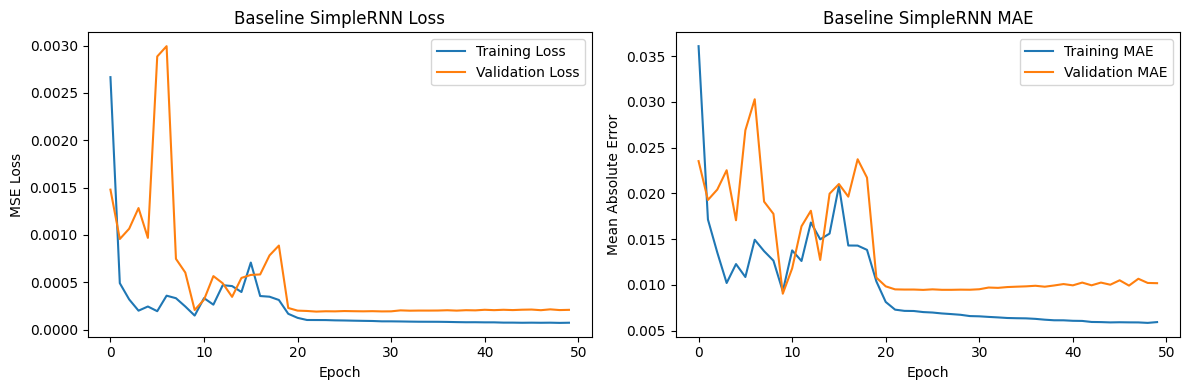

I0000 00:00:1780107725.727798  258892 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


16/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

I0000 00:00:1780107728.657818  258891 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 129ms/step
1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step

I0000 00:00:1780107731.535470  258891 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 541ms/step
Baseline SimpleRNN Train RMSE: 401.42
Baseline SimpleRNN Test RMSE: 2067.57
Baseline SimpleRNN Train MAE: 270.35
Baseline SimpleRNN Test MAE: 1470.13


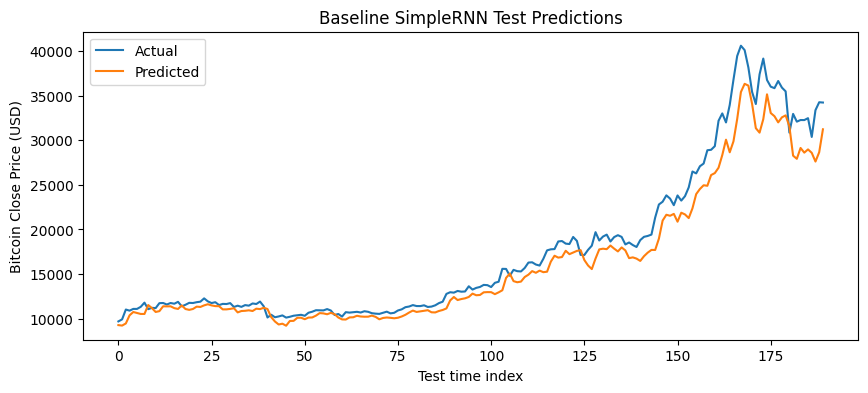

In [32]:
# Build and train baseline SimpleRNN model

simple_rnn_model = Sequential([
    SimpleRNN(
        128,                                     # small baseline recurrent layer
        activation="tanh",                     # standard activation for SimpleRNN
        input_shape=(look_back, trainX_bitcoin.shape[2])
    ),                                         # input shape = timesteps, features
    tf.keras.layers.Dense(32, activation='relu'),
    Dense(1)                                   # output layer: predict next close_USD value
])

simple_rnn_model.compile(
    optimizer="adam",                          # adaptive gradient-based optimizer
    loss="mean_squared_error",                 # regression loss
    metrics=["mean_absolute_error"]            # easier-to-interpret training metric
)

simple_rnn_history = simple_rnn_model.fit(
    trainX_bitcoin,
    trainY_bitcoin,
    epochs=50,                                 # baseline training limit
    batch_size=16,                             # update weights after each batch
    validation_split=0.2,                      # last 20% of training data used for validation
    shuffle=False,                             # preserve chronological order
    verbose=1
)

# Visualize SimpleRNN training performance

plot_training_curves(
    simple_rnn_history,
    "Baseline SimpleRNN"
)

# Evaluate SimpleRNN on held-out future test data

evaluate_and_plot(
    simple_rnn_model,
    trainX_bitcoin,
    testX_bitcoin,
    trainY_bitcoin,
    testY_bitcoin,
    scaler_bitcoin,
    target_index,
    "Baseline SimpleRNN"
)

In [34]:
simple_rnn_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 128)            │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,941 (249.77 KB)

 Trainable params: 21,313 (83.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 42,628 (166.52 KB)

All it took to increase the model was to vastly increase the model capacity, which now has 21,313 trainable parameters, from 121 previously.

#### LSTM Improvement: Add capacity, add Early Stopping (patience of 10) and increase the lookback window from 10 to 12

Epoch 1/50


/home/jfigg/miniforge3/envs/keras_env_wsl/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - loss: 0.0012 - mean_absolute_error: 0.0275 - val_loss: 0.0016 - val_mean_absolute_error: 0.0348
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0019 - mean_absolute_error: 0.0346 - val_loss: 6.9337e-04 - val_mean_absolute_error: 0.0219
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0010 - mean_absolute_error: 0.0253 - val_loss: 6.2448e-04 - val_mean_absolute_error: 0.0161
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0010 - mean_absolute_error: 0.0248 - val_loss: 4.4985e-04 - val_mean_absolute_error: 0.0143
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 8.7337e-04 - mean_absolute_error: 0.0228 - val_loss: 4.5732e-04 - val_mean_absolute_error: 0.0147
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 4.7705e-04 - mean_absolute_error: 0.0162 - val_loss: 5.9481e-04 - val_mean_absolute_error: 0.0178
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 5.9255e-04 - mean_absolute_err

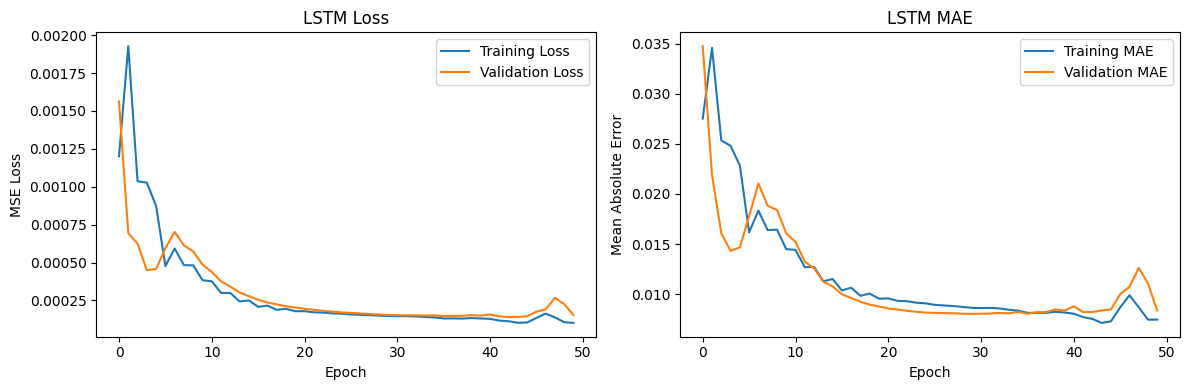

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
LSTM Train RMSE: 367.71
LSTM Test RMSE: 1459.03
LSTM Train MAE: 244.86
LSTM Test MAE: 1031.24


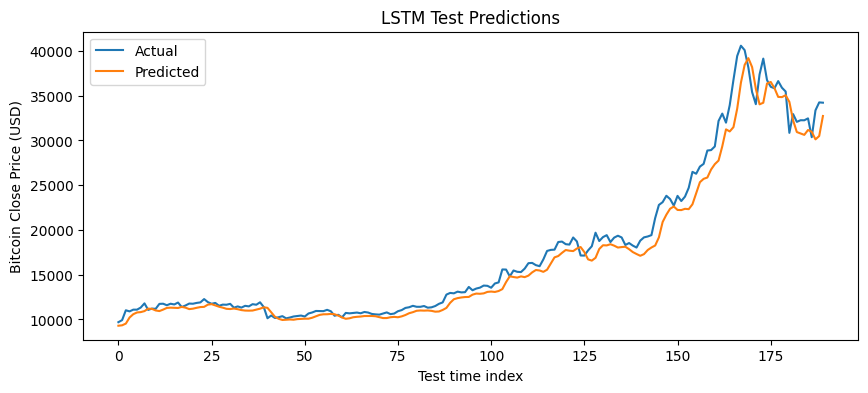

In [43]:
# Build and train baseline LSTM model

look_back = 12

lstm_model = Sequential([
    LSTM(
        128,                                     # small baseline LSTM layer
        activation="tanh",                     # standard LSTM hidden-state activation
        input_shape=(look_back, trainX_bitcoin.shape[2])
    ),                                         # input shape = timesteps, features
    tf.keras.layers.Dense(32, activation='relu'),
    Dense(1)                                   # output layer: predict next close_USD value
])

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

lstm_model.compile(
    optimizer="adam",                          # adaptive gradient-based optimizer
    loss="mean_squared_error",                 # regression loss
    metrics=["mean_absolute_error"]            # easier-to-interpret training metric
)

lstm_history = lstm_model.fit(
    trainX_bitcoin,
    trainY_bitcoin,
    epochs=50,                                 # baseline training limit
    batch_size=16,                             # update weights after each batch
    validation_split=0.2,                      # last 20% of training data used for validation
    shuffle=False,                             # preserve chronological order
    callbacks=[early_stopping],
    verbose=1
)

plot_training_curves(
    lstm_history,
    "LSTM"
)

evaluate_and_plot(
    lstm_model,
    trainX_bitcoin,
    testX_bitcoin,
    trainY_bitcoin,
    testY_bitcoin,
    scaler_bitcoin,
    target_index,
    "LSTM"
)

The LSTM model slightly improved from the baseline with the same treatment as the SimpleRNN model; however, when I added batch normalization after the first dense layer, and added a second dense layer, the model actually got worse.  Removing this normalization and decreasing the capacity led to a better fitting model.  Increasing the lookback window vastly improved the model, with it nearly rivaling the xgboost model in terms of test loss.

#### GRU Improvement: Use the MUON optimizer instead of ADAM, increase look_back to 15 and add more capacity.

Epoch 1/50


/home/jfigg/miniforge3/envs/keras_env_wsl/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.0021 - mean_absolute_error: 0.0381 - val_loss: 3.9165e-04 - val_mean_absolute_error: 0.0166
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 3.6367e-04 - mean_absolute_error: 0.0149 - val_loss: 4.2620e-04 - val_mean_absolute_error: 0.0178
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 8.3898e-04 - mean_absolute_error: 0.0220 - val_loss: 5.8620e-04 - val_mean_absolute_error: 0.0185
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 8.9318e-04 - mean_absolute_error: 0.0238 - val_loss: 7.7165e-04 - val_mean_absolute_error: 0.0235
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0016 - mean_absolute_error: 0.0294 - val_loss: 0.0024 - val_mean_absolute_error: 0.0454
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0026 - mean_absolute_error: 0.0419 - val_loss: 5.7028e-04 - val_mean_absolute_error: 0.0190
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0015 - mean_absolute_err

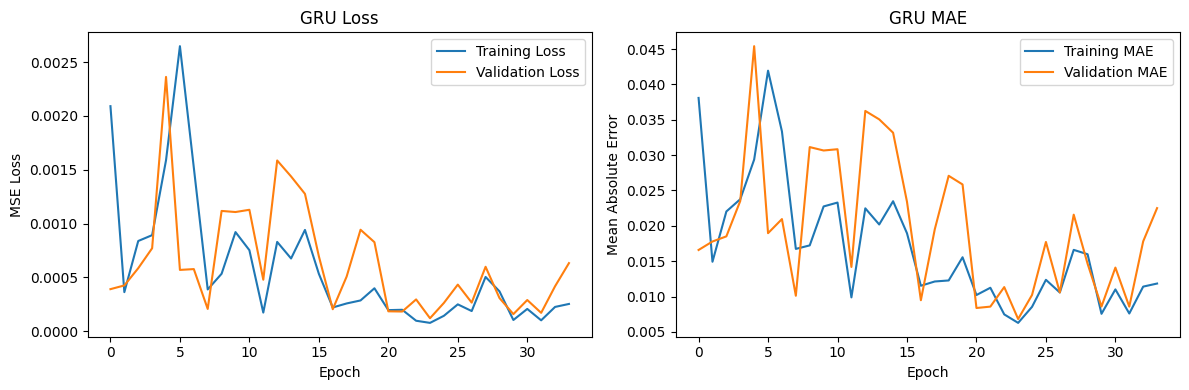

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
GRU Train RMSE: 344.21
GRU Test RMSE: 1748.73
GRU Train MAE: 236.15
GRU Test MAE: 1072.39


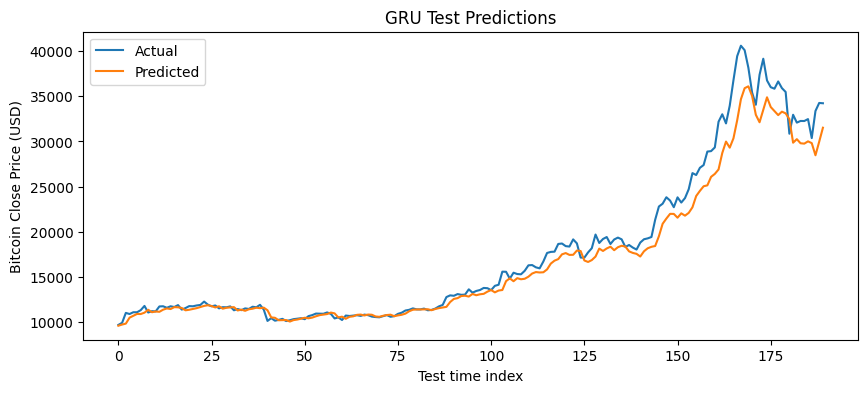

In [46]:
# Build and train baseline GRU model

look_back = 15

gru_model = Sequential([
    GRU(
        128,                                     # small baseline LSTM layer
        activation="tanh",                     # standard LSTM hidden-state activation
        input_shape=(look_back, trainX_bitcoin.shape[2])
    ),                                         # input shape = timesteps, features
    tf.keras.layers.Dense(32, activation='relu'),
    Dense(1)                                   # output layer: predict next close_USD value
])

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

gru_model.compile(
    optimizer="muon",                          # adaptive gradient-based optimizer
    loss="mean_squared_error",                 # regression loss
    metrics=["mean_absolute_error"]            # easier-to-interpret training metric
)

gru_history = gru_model.fit(
    trainX_bitcoin,
    trainY_bitcoin,
    epochs=50,                                 # baseline training limit
    batch_size=16,                             # update weights after each batch
    validation_split=0.2,                      # last 20% of training data used for validation
    shuffle=False,                             # preserve chronological order
    callbacks=[early_stopping],
    verbose=1
)

plot_training_curves(
    gru_history,
    "GRU"
)

evaluate_and_plot(
    gru_model,
    trainX_bitcoin,
    testX_bitcoin,
    trainY_bitcoin,
    testY_bitcoin,
    scaler_bitcoin,
    target_index,
    "GRU"
)

Increasing the lookback window of the GRU model to 15 seems to have made losses more noisy; I think the fix is to reduce the training rate:

/home/jfigg/miniforge3/envs/keras_env_wsl/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - loss: 0.0022 - mean_absolute_error: 0.0378 - val_loss: 0.0011 - val_mean_absolute_error: 0.0289
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0017 - mean_absolute_error: 0.0318 - val_loss: 4.8976e-04 - val_mean_absolute_error: 0.0157
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0011 - mean_absolute_error: 0.0262 - val_loss: 9.5784e-04 - val_mean_absolute_error: 0.0243
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.0013 - mean_absolute_error: 0.0272 - val_loss: 0.0016 - val_mean_absolute_error: 0.0361
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 9.8568e-04 - mean_absolute_error: 0.0248 - val_loss: 0.0012 - val_mean_absolute_error: 0.0315
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 7.6033e-04 - mean_absolute_error: 0.0217 - val_loss: 9.4080e-04 - val_mean_absolute_error: 0.0272
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 5.4703e-04 - mean_absolute_

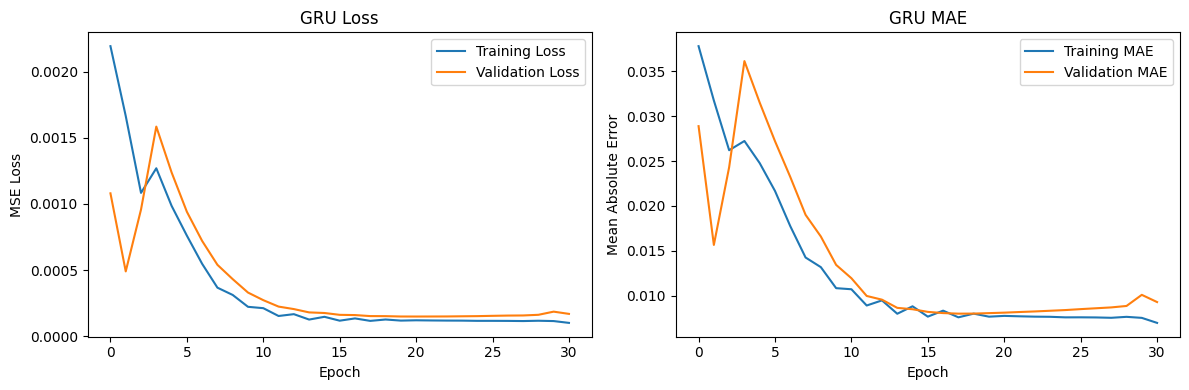

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
GRU Train RMSE: 380.77
GRU Test RMSE: 1746.24
GRU Train MAE: 266.75
GRU Test MAE: 1168.50


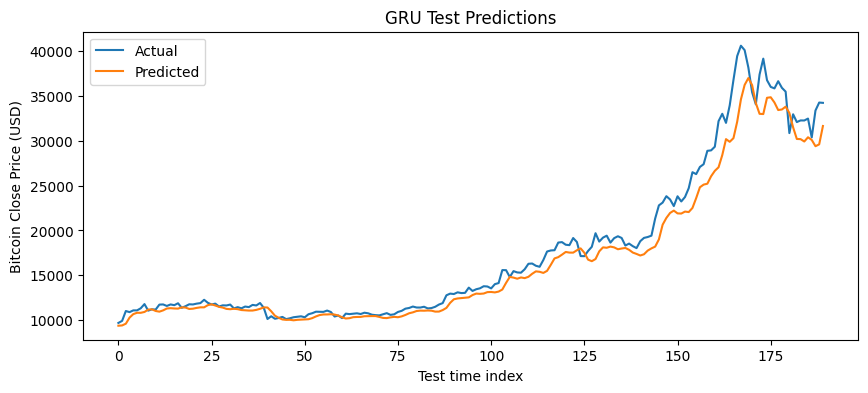

In [49]:
# Build and train baseline GRU model

look_back = 15

gru_model = Sequential([
    GRU(
        128,                                     # small baseline LSTM layer
        activation="tanh",                     # standard LSTM hidden-state activation
        input_shape=(look_back, trainX_bitcoin.shape[2])
    ),                                         # input shape = timesteps, features
    tf.keras.layers.Dense(32, activation='relu'),
    Dense(1)                                   # output layer: predict next close_USD value
])

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

gru_model.compile(
    optimizer=tf.keras.optimizers.Adam(),                          # adaptive gradient-based optimizer
    loss="mean_squared_error",                 # regression loss
    metrics=["mean_absolute_error"]            # easier-to-interpret training metric
)

gru_history = gru_model.fit(
    trainX_bitcoin,
    trainY_bitcoin,
    epochs=50,                                 # baseline training limit
    batch_size=16,                             # update weights after each batch
    validation_split=0.2,                      # last 20% of training data used for validation
    shuffle=False,                             # preserve chronological order
    callbacks=[early_stopping],
    verbose=1
)

plot_training_curves(
    gru_history,
    "GRU"
)

evaluate_and_plot(
    gru_model,
    trainX_bitcoin,
    testX_bitcoin,
    trainY_bitcoin,
    testY_bitcoin,
    scaler_bitcoin,
    target_index,
    "GRU"
)

NOTE: Reducing the training rate (from the default of .001 to .0001) helped smooth out the training and validation curves, but the model wasn't as good, so I switched back to the default Adam optimizer.  I don't think Muon is as good for this use case, and I don't know how to define its parameters optimally.

### Your summary

Based on the model outputs, the LSTM was the strongest recurrent model overall, although it may not be statistically significant, given that I don't set a random seed and am on GPU, so the models can show decent changes with each new rerun.

| Model | Main changes tested | Lookback window | Optimizer / callback | Train RMSE | Test RMSE | Train MAE | Test MAE | Takeaway |
|---|---|---:|---|---:|---:|---:|---:|---|
| SimpleRNN | Increased recurrent capacity to 128 units and added a 32-unit dense layer | 10 | Adam, no early stopping | 401.42 | 2067.57 | 270.35 | 1470.13 | Improved capacity helped, but it still had the weakest test performance and the largest train-test gap. |
| LSTM | Increased capacity, added a 32-unit dense layer, added early stopping, and increased lookback | 12 | Adam with early stopping, patience 10 | 367.71 | 1459.03 | 244.86 | 1031.24 | Best overall recurrent model; the longer lookback window helped it generalize better. |
| GRU | Increased capacity, tested Muon, then switched back to Adam with early stopping | 15 | Adam with early stopping, patience 10 | 380.77 | 1746.24 | 266.75 | 1168.50 | Better than SimpleRNN but not as strong as LSTM; the longer lookback may have made training noisier. |

_______________________________________________________________________________________________________________________________

_______________________________________________________________________________________________________________________________

### Do you need RNN for time series data?

#### XGB with lagged features

Plotting function for nonscaled models

In [24]:
# Generic prediction plotting function for models already on the original scale

def plot_predictions(actual, predicted, title):

    plt.figure(figsize=(10, 4))

    plt.plot(actual, label="Actual")
    plt.plot(predicted, label="Predicted")

    plt.title(title)
    plt.xlabel("Test time index")
    plt.ylabel("Bitcoin Close Price (USD)")

    plt.ticklabel_format(style="plain", axis="y")

    plt.legend()
    plt.show()

XGB Data preparation

In [25]:
# Create lagged features for XGBoost

xgb_data = bitcoin[["date"] + features].copy()

lag_days = 10

for lag in range(1, lag_days + 1):
    for col in features:
        xgb_data[f"{col}_lag{lag}"] = xgb_data[col].shift(lag)

xgb_data["target_close_USD"] = xgb_data["close_USD"]

xgb_data = xgb_data.dropna().reset_index(drop=True)

xgb_data.head()

,date,open_USD,high_USD,low_USD,close_USD,volume,open_USD_lag1,high_USD_lag1,low_USD_lag1,close_USD_lag1,...,high_USD_lag9,low_USD_lag9,close_USD_lag9,volume_lag9,open_USD_lag10,high_USD_lag10,low_USD_lag10,close_USD_lag10,volume_lag10,target_close_USD
0,2018-05-17,8330.00,8464.00,7979.00,8041.46,25439,8462.00,8488.00,8083.01,8330.00,...,9475.70,9060.54,9187.56,25533.0,9661.02,9689.67,9181.00,9365.00,33787.0,8041.46
1,2018-05-18,8038.82,8273.21,7911.90,8239.81,23476,8330.00,8464.00,7979.00,8041.46,...,9390.00,8965.00,9310.00,25673.0,9365.00,9475.70,9060.54,9187.56,25533.0,8239.81
2,2018-05-19,8238.01,8390.80,8095.73,8233.49,17193,8038.82,8273.21,7911.90,8239.81,...,9395.12,8970.00,9002.20,25055.0,9178.00,9390.00,8965.00,9310.00,25673.0,8233.49
3,2018-05-20,8233.49,8609.00,8163.90,8526.98,19957,8238.01,8390.80,8095.73,8233.49,...,9016.80,8341.00,8400.00,48227.0,9310.00,9395.12,8970.00,9002.20,25055.0,8526.98
4,2018-05-21,8526.97,8595.31,8305.00,8381.24,21516,8233.49,8609.00,8163.90,8526.98,...,8646.88,8153.00,8465.94,40241.0,9002.21,9016.80,8341.00,8400.00,48227.0,8381.24


XGB train test preparation

In [26]:
# Prepare XGBoost train/test data

xgb_features = [
    col for col in xgb_data.columns
    if "lag" in col
]

X_xgb = xgb_data[xgb_features]
y_xgb = xgb_data["target_close_USD"]

train_size_xgb = int(len(xgb_data) * 0.8)

trainX_xgb = X_xgb.iloc[:train_size_xgb]
testX_xgb = X_xgb.iloc[train_size_xgb:]

trainY_xgb = y_xgb.iloc[:train_size_xgb]
testY_xgb = y_xgb.iloc[train_size_xgb:]

print("trainX_xgb shape:", trainX_xgb.shape)
print("testX_xgb shape:", testX_xgb.shape)
print("trainY_xgb shape:", trainY_xgb.shape)
print("testY_xgb shape:", testY_xgb.shape)

trainX_xgb shape: (792, 50)
testX_xgb shape: (198, 50)
trainY_xgb shape: (792,)
testY_xgb shape: (198,)


Build & train model

In [27]:
# Build and train baseline XGBoost model

from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(
    trainX_xgb,
    trainY_xgb
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

Evaluating on test data

In [28]:
# Evaluate XGBoost baseline on held-out future test data

xgb_test_pred = xgb_model.predict(testX_xgb)

xgb_rmse = np.sqrt(mean_squared_error(testY_xgb, xgb_test_pred))
xgb_mae = mean_absolute_error(testY_xgb, xgb_test_pred)

print(f"Baseline XGBoost Test RMSE: {xgb_rmse:.2f}")
print(f"Baseline XGBoost Test MAE: {xgb_mae:.2f}")

Baseline XGBoost Test RMSE: 10490.81
Baseline XGBoost Test MAE: 6340.83


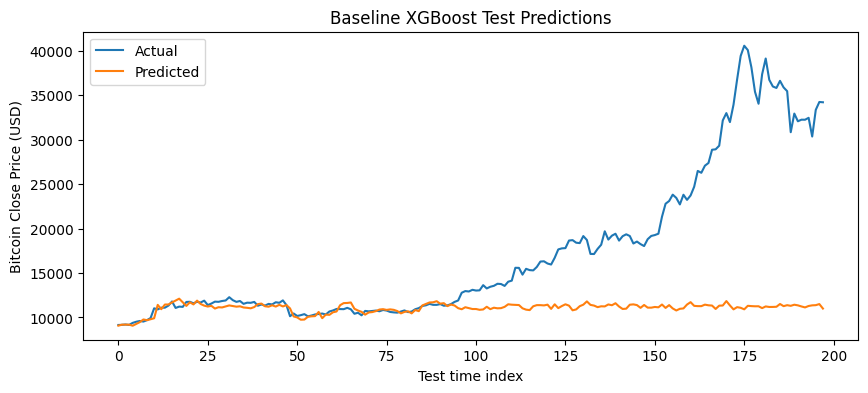

In [29]:
# Visualize baselineXGBoost predictions

plot_predictions(
    testY_xgb.values,
    xgb_test_pred,
    "Baseline XGBoost Test Predictions"
)

Modifying the XGB target to percent change instead of raw price

Improved XGBoost Test RMSE: 892.54
Improved XGBoost Test MAE: 550.68


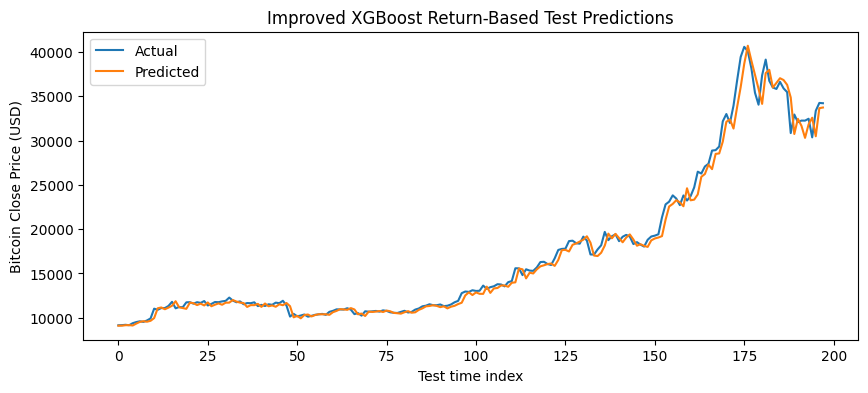

In [30]:
# Improved XGBoost: predict next-day percent change instead of raw price

xgb_return_data = bitcoin[["date"] + features].copy()

xgb_return_data["close_return"] = (
    xgb_return_data["close_USD"]
    .pct_change()
)                                                               # calculate daily percent return

lag_days = 10                                                   # use previous 10 days as predictors

for lag in range(1, lag_days + 1):

    for col in features:
        xgb_return_data[f"{col}_lag{lag}"] = (
            xgb_return_data[col]
            .shift(lag)
        )                                                       # previous feature values become lag predictors

    xgb_return_data[f"close_return_lag{lag}"] = (
        xgb_return_data["close_return"]
        .shift(lag)
    )                                                           # include lagged returns as predictors

xgb_return_data["target_return"] = (
    xgb_return_data["close_return"]
    .shift(-1)
)                                                               # predict next-day return

xgb_return_data["current_close_USD"] = (
    xgb_return_data["close_USD"]
)                                                               # keep current close price for reconstruction later

xgb_return_data = (
    xgb_return_data
    .dropna()
    .reset_index(drop=True)
)                                                               # remove rows without sufficient lag history

xgb_return_features = [
    col for col in xgb_return_data.columns
    if "lag" in col
]                                                               # use lagged values as predictors

X_xgb_return = xgb_return_data[xgb_return_features]
y_xgb_return = xgb_return_data["target_return"]

train_size_xgb_return = int(len(xgb_return_data) * 0.8)        # chronological 80/20 split

trainX_xgb_return = X_xgb_return.iloc[:train_size_xgb_return]
testX_xgb_return = X_xgb_return.iloc[train_size_xgb_return:]

trainY_xgb_return = y_xgb_return.iloc[:train_size_xgb_return]
testY_xgb_return = y_xgb_return.iloc[train_size_xgb_return:]

test_current_close = (
    xgb_return_data["current_close_USD"]
    .iloc[train_size_xgb_return:]
)                                                               # current price used to reconstruct next-day prediction

xgb_return_model = XGBRegressor(
    n_estimators=300,                                           # more trees for stronger learning
    max_depth=2,                                                # shallow trees reduce overfitting
    learning_rate=0.03,                                         # smaller learning steps
    subsample=0.8,                                              # random row sampling
    colsample_bytree=0.8,                                       # random feature sampling
    objective="reg:squarederror",
    random_state=42
)

xgb_return_model.fit(
    trainX_xgb_return,
    trainY_xgb_return
)

xgb_return_pred = xgb_return_model.predict(
    testX_xgb_return
)                                                               # predict next-day percent return

xgb_return_price_pred = (
    test_current_close.values * (1 + xgb_return_pred)
)                                                               # convert predicted return back to predicted price

xgb_return_price_actual = (
    test_current_close.values * (1 + testY_xgb_return.values)
)                                                               # actual next-day price

xgb_return_rmse = np.sqrt(
    mean_squared_error(
        xgb_return_price_actual,
        xgb_return_price_pred
    )
)

xgb_return_mae = mean_absolute_error(
    xgb_return_price_actual,
    xgb_return_price_pred
)

print(f"Improved XGBoost Test RMSE: {xgb_return_rmse:.2f}")
print(f"Improved XGBoost Test MAE: {xgb_return_mae:.2f}")

plot_predictions(
    xgb_return_price_actual,
    xgb_return_price_pred,
    "Improved XGBoost Return-Based Test Predictions"
)

In [31]:
# Compare baseline model performance

simple_rnn_rmse, simple_rnn_mae = evaluate_metrics(
    simple_rnn_model,
    testX_bitcoin,
    testY_bitcoin,
    scaler_bitcoin,
    target_index
)

lstm_rmse, lstm_mae = evaluate_metrics(
    lstm_model,
    testX_bitcoin,
    testY_bitcoin,
    scaler_bitcoin,
    target_index
)

gru_rmse, gru_mae = evaluate_metrics(
    gru_model,
    testX_bitcoin,
    testY_bitcoin,
    scaler_bitcoin,
    target_index
)

model_comparison = pd.DataFrame({
    "Model": [
        "SimpleRNN",
        "LSTM",
        "GRU",
        "XGBoost raw price target",
        "XGBoost return target"
    ],

    "RMSE": [
        simple_rnn_rmse,
        lstm_rmse,
        gru_rmse,
        xgb_rmse,
        xgb_return_rmse
    ],

    "MAE": [
        simple_rnn_mae,
        lstm_mae,
        gru_mae,
        xgb_mae,
        xgb_return_mae
    ]
})

model_comparison.sort_values("RMSE")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


,Model,RMSE,MAE
4,XGBoost return target,892.536704,550.684864
1,LSTM,2398.892255,1580.675897
2,GRU,4731.790649,3247.636632
0,SimpleRNN,7800.416132,4305.723756
3,XGBoost raw price target,10490.806519,6340.832358
